In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
# Import matplotlib for creating graphs
import matplotlib.pyplot as plt

# Import Google Colab file upload function
from google.colab import files

In [ ]:
# Upload the synthetic registration queue dataset
print("Please upload the CSV dataset.")

uploaded = files.upload()

Please upload the CSV dataset.


Saving EEI6373_Registration_Queue_Synthetic_Dataset_Cleaned.csv to EEI6373_Registration_Queue_Synthetic_Dataset_Cleaned (4).csv


In [ ]:
# Get the name of the uploaded file
file_name = list(uploaded.keys())[0]

# Read the CSV dataset
df = pd.read_csv(file_name)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
# Display the first five rows
print("First 5 Rows of the Registration Queue Dataset:")
print(df.head())

First 5 Rows of the Registration Queue Dataset:
  Student_ID Scenario  Arrival_Rate_students_per_hour  Interarrival_Time_min  \
0       S001   Normal                              10                   0.00   
1       S002   Normal                              10                   0.14   
2       S003   Normal                              10                   8.72   
3       S004   Normal                              10                   0.15   
4       S005   Normal                              10                  18.57   

   Arrival_Time_min Arrival_Time  Service_Time_min  
0              0.00     08:00:00              9.51  
1              0.14     08:00:08              3.07  
2              8.86     08:08:51              3.16  
3              9.00     08:09:00              7.02  
4             27.57     08:27:34              0.69  


In [ ]:
# Display the number of rows and columns
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(300, 7)


In [ ]:
# Display information about the dataset
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Student_ID                      300 non-null    object 
 1   Scenario                        300 non-null    object 
 2   Arrival_Rate_students_per_hour  300 non-null    int64  
 3   Interarrival_Time_min           300 non-null    float64
 4   Arrival_Time_min                300 non-null    float64
 5   Arrival_Time                    300 non-null    object 
 6   Service_Time_min                300 non-null    float64
dtypes: float64(3), int64(1), object(3)
memory usage: 16.5+ KB


In [ ]:
# Display statistical information for numerical variables
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       Arrival_Rate_students_per_hour  Interarrival_Time_min  \
count                      300.000000             300.000000   
mean                        18.333333               3.596800   
std                          6.246515               4.912216   
min                         10.000000               0.000000   
25%                         10.000000               0.825000   
50%                         20.000000               2.145000   
75%                         25.000000               4.230000   
max                         25.000000              39.990000   

       Arrival_Time_min  Service_Time_min  
count        300.000000        300.000000  
mean         186.140800          3.999700  
std          140.751081          3.885086  
min            0.000000          0.000000  
25%           85.610000          1.135000  
50%          158.780000          2.975000  
75%          226.710000          5.557500  
max          608.150000         29.420000  


In [ ]:
# Display the number of students in each workload scenario
print("\nStudents in Each Scenario:")
print(df["Scenario"].value_counts())


Students in Each Scenario:
Scenario
Normal    100
High      100
Peak      100
Name: count, dtype: int64


In [ ]:
# Display the arrival rate used for each scenario
print("\nArrival Rate for Each Scenario:")
print(df.groupby("Scenario")["Arrival_Rate_students_per_hour"].first())


Arrival Rate for Each Scenario:
Scenario
High      20
Normal    10
Peak      25
Name: Arrival_Rate_students_per_hour, dtype: int64


In [ ]:
# Calculate the average service time for each scenario
print("\nAverage Service Time for Each Scenario:")
print(df.groupby("Scenario")["Service_Time_min"].mean().round(2))


Average Service Time for Each Scenario:
Scenario
High      4.0
Normal    4.0
Peak      4.0
Name: Service_Time_min, dtype: float64


In [ ]:
# SIMULATION SETTINGS

# Number of students simulated in each replication
NUM_STUDENTS = 100

# Number of independent simulation replications
NUM_REPLICATIONS = 30

# Average registration service time from our dataset
AVERAGE_SERVICE_TIME = df["Service_Time_min"].mean()

# Arrival rates for each workload scenario
SCENARIO_RATES = {
    "Normal": 10,
    "High": 20,
    "Peak": 25
}

print("Simulation settings:")
print(f"Students per replication: {NUM_STUDENTS}")
print(f"Number of replications: {NUM_REPLICATIONS}")
print(f"Average service time: {AVERAGE_SERVICE_TIME:.2f} minutes")
print(f"Scenario arrival rates: {SCENARIO_RATES}")

Simulation settings:
Students per replication: 100
Number of replications: 30
Average service time: 4.00 minutes
Scenario arrival rates: {'Normal': 10, 'High': 20, 'Peak': 25}


In [ ]:
# SINGLE-SERVER QUEUE SIMULATION

def simulate_registration_queue(
    arrival_rate,
    num_students,
    average_service_time,
    random_seed
):
    """
    Simulates the university registration queue.

    System:
    - One registration officer
    - One waiting queue
    - First-Come, First-Served (FCFS)
    """

    # Create a random number generator for this replication
    rng = np.random.default_rng(random_seed)

    # Mean time between student arrivals in minutes
    mean_interarrival_time = 60 / arrival_rate

    # Generate random inter-arrival times
    interarrival_times = rng.exponential(
        scale=mean_interarrival_time,
        size=num_students
    )

    # Convert inter-arrival times into arrival times
    arrival_times = np.cumsum(interarrival_times)

    # Generate random registration service times
    service_times = rng.exponential(
        scale=average_service_time,
        size=num_students
    )

    # The registration officer is initially available at time 0
    officer_free_time = 0.0

    # Store results for each student
    simulation_results = []

    # Process students in arrival order
    for student_number in range(num_students):

        # Student arrival time
        arrival_time = arrival_times[student_number]

        # Student service time
        service_time = service_times[student_number]

        # Service starts when both the student and officer are available
        service_start_time = max(
            arrival_time,
            officer_free_time
        )

        # Calculate waiting time
        waiting_time = (
            service_start_time - arrival_time
        )

        # Calculate service completion time
        completion_time = (
            service_start_time + service_time
        )

        # Calculate total time spent in the system
        time_in_system = (
            completion_time - arrival_time
        )

        # Store the student's results
        simulation_results.append({
            "Student_Number": student_number + 1,
            "Arrival_Time_min": arrival_time,
            "Service_Time_min": service_time,
            "Service_Start_Time_min": service_start_time,
            "Completion_Time_min": completion_time,
            "Waiting_Time_min": waiting_time,
            "Time_in_System_min": time_in_system
        })

        # Officer becomes available after serving this student
        officer_free_time = completion_time

    # Convert the results into a DataFrame
    return pd.DataFrame(simulation_results)

In [ ]:
# 4. TEST THE SIMULATION

# Run one test simulation using the Normal workload
test_results = simulate_registration_queue(
    arrival_rate=10,
    num_students=100,
    average_service_time=AVERAGE_SERVICE_TIME,
    random_seed=1
)

# Display the first five simulated students
print("First 5 students from the test simulation:")
display(test_results.head())

First 5 students from the test simulation:


,Student_Number,Arrival_Time_min,Service_Time_min,Service_Start_Time_min,Completion_Time_min,Waiting_Time_min,Time_in_System_min
0,1,6.438174,14.326673,6.438174,20.764847,0.000000,14.326673
1,2,8.288893,9.714081,20.764847,30.478929,12.475954,22.190035
2,3,40.541514,2.607428,40.541514,43.148942,0.000000,2.607428
3,4,42.740077,3.854611,43.148942,47.003554,0.408865,4.263477
4,5,43.432249,0.610174,47.003554,47.613728,3.571305,4.181479


In [ ]:
# 5. PERFORMANCE METRICS

def calculate_performance_metrics(results):

    # Total observation time of the simulation
    simulation_end_time = (
        results["Completion_Time_min"].max()
    )

    # Total time the registration officer was busy
    total_service_time = (
        results["Service_Time_min"].sum()
    )

    # Average student waiting time
    average_waiting_time = (
        results["Waiting_Time_min"].mean()
    )

    # Median student waiting time
    median_waiting_time = (
        results["Waiting_Time_min"].median()
    )

    # 95th percentile waiting time
    p95_waiting_time = (
        results["Waiting_Time_min"].quantile(0.95)
    )

    # Maximum waiting time
    maximum_waiting_time = (
        results["Waiting_Time_min"].max()
    )

    # Average total time spent in the system
    average_time_in_system = (
        results["Time_in_System_min"].mean()
    )

    # Average queue length
    # Based on Little's Law:
    # Lq = Total waiting time / Observation time
    average_queue_length = (
        results["Waiting_Time_min"].sum()
        / simulation_end_time
    )

    # Throughput in students per hour
    throughput = (
        len(results)
        / (simulation_end_time / 60)
    )

    # Registration officer utilization
    officer_utilization = (
        total_service_time
        / simulation_end_time
    ) * 100

    return {
        "Average Waiting Time (min)": average_waiting_time,
        "Median Waiting Time (min)": median_waiting_time,
        "P95 Waiting Time (min)": p95_waiting_time,
        "Maximum Waiting Time (min)": maximum_waiting_time,
        "Average Time in System (min)": average_time_in_system,
        "Average Queue Length": average_queue_length,
        "Throughput (students/hour)": throughput,
        "Officer Utilization (%)": officer_utilization
    }

In [ ]:
# 6. MULTIPLE SIMULATION REPLICATIONS

# Store results from every replication
all_replication_results = []

# Run each workload scenario
for scenario, arrival_rate in SCENARIO_RATES.items():

    # Run 30 independent replications
    for replication in range(1, NUM_REPLICATIONS + 1):

        # Use a different random seed for each replication
        random_seed = replication

        # Run the queue simulation
        results = simulate_registration_queue(
            arrival_rate=arrival_rate,
            num_students=NUM_STUDENTS,
            average_service_time=AVERAGE_SERVICE_TIME,
            random_seed=random_seed
        )

        # Calculate performance metrics
        metrics = calculate_performance_metrics(results)

        # Add scenario information
        metrics["Scenario"] = scenario
        metrics["Replication"] = replication
        metrics["Arrival Rate (students/hour)"] = arrival_rate

        # Store the results
        all_replication_results.append(metrics)

# Convert all replication results to a DataFrame
replication_df = pd.DataFrame(all_replication_results)

print("Simulation completed successfully.")
print(f"Total simulation runs: {len(replication_df)}")

Simulation completed successfully.
Total simulation runs: 90


In [ ]:
# 7. FINAL PERFORMANCE SUMMARY

# Calculate the mean performance across the 30 replications
performance_summary = (
    replication_df
    .groupby("Scenario")
    .agg({
        "Arrival Rate (students/hour)": "first",
        "Average Waiting Time (min)": "mean",
        "Median Waiting Time (min)": "mean",
        "P95 Waiting Time (min)": "mean",
        "Maximum Waiting Time (min)": "mean",
        "Average Time in System (min)": "mean",
        "Average Queue Length": "mean",
        "Throughput (students/hour)": "mean",
        "Officer Utilization (%)": "mean"
    })
    .reset_index()
)

# Keep scenarios in the correct order
scenario_order = ["Normal", "High", "Peak"]

performance_summary["Scenario"] = pd.Categorical(
    performance_summary["Scenario"],
    categories=scenario_order,
    ordered=True
)

performance_summary = (
    performance_summary
    .sort_values("Scenario")
    .reset_index(drop=True)
)

# Round values for easier reading
performance_summary = performance_summary.round(2)

print("Final Performance Summary:")
display(performance_summary)

Final Performance Summary:


,Scenario,Arrival Rate (students/hour),Average Waiting Time (min),Median Waiting Time (min),P95 Waiting Time (min),Maximum Waiting Time (min),Average Time in System (min),Average Queue Length,Throughput (students/hour),Officer Utilization (%)
0,Normal,10,6.89,3.91,23.95,32.37,11.04,1.14,9.87,67.99
1,High,20,65.31,67.27,117.29,125.89,69.45,15.29,14.40,98.48
2,Peak,25,93.05,95.74,168.44,176.99,97.20,22.04,14.48,99.01


In [ ]:
# 8. VARIABILITY BETWEEN REPLICATIONS

# Calculate standard deviation across the 30 replications
performance_std = (
    replication_df
    .groupby("Scenario")
    .agg({
        "Average Waiting Time (min)": "std",
        "Average Queue Length": "std",
        "Throughput (students/hour)": "std",
        "Officer Utilization (%)": "std"
    })
    .reset_index()
)

performance_std = performance_std.round(2)

print("Variation Across Simulation Replications:")
display(performance_std)

Variation Across Simulation Replications:


,Scenario,Average Waiting Time (min),Average Queue Length,Throughput (students/hour),Officer Utilization (%)
0,High,22.53,4.53,1.51,1.49
1,Normal,3.66,0.64,0.93,8.19
2,Peak,22.54,4.05,1.52,0.96


In [ ]:
# 9. SAVE SIMULATION RESULTS

# Save the final average performance results
performance_summary.to_csv(
    "EEI6373_Registration_Queue_Performance_Summary.csv",
    index=False
)

# Save results from every individual replication
replication_df.to_csv(
    "EEI6373_Registration_Queue_Replication_Results.csv",
    index=False
)

print("Simulation results saved successfully.")

Simulation results saved successfully.


In [ ]:
# 9.1 DOWNLOAD SIMULATION RESULTS

from google.colab import files

# Download the final performance summary
files.download(
    "EEI6373_Registration_Queue_Performance_Summary.csv"
)

# Download all individual replication results
files.download(
    "EEI6373_Registration_Queue_Replication_Results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

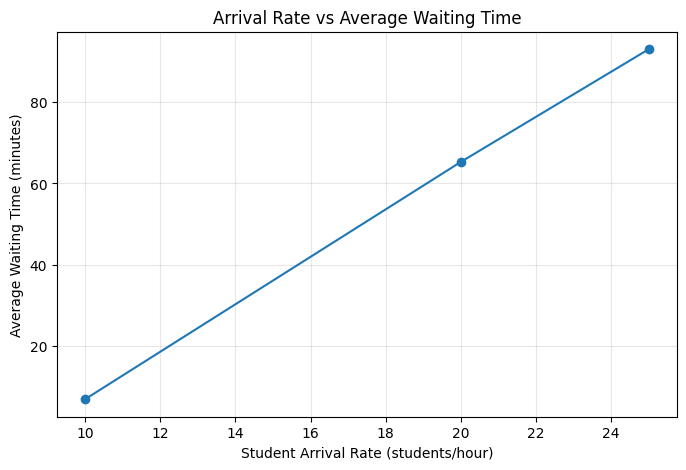

In [ ]:
# 10. GRAPH 1 - AVERAGE WAITING TIME

plt.figure(figsize=(8, 5))

plt.plot(
    performance_summary["Arrival Rate (students/hour)"],
    performance_summary["Average Waiting Time (min)"],
    marker="o"
)

plt.xlabel("Student Arrival Rate (students/hour)")
plt.ylabel("Average Waiting Time (minutes)")
plt.title("Arrival Rate vs Average Waiting Time")

plt.grid(True, alpha=0.3)

# Save the graph as a high-resolution image
plt.savefig(
    "EEI6373_Average_Waiting_Time.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

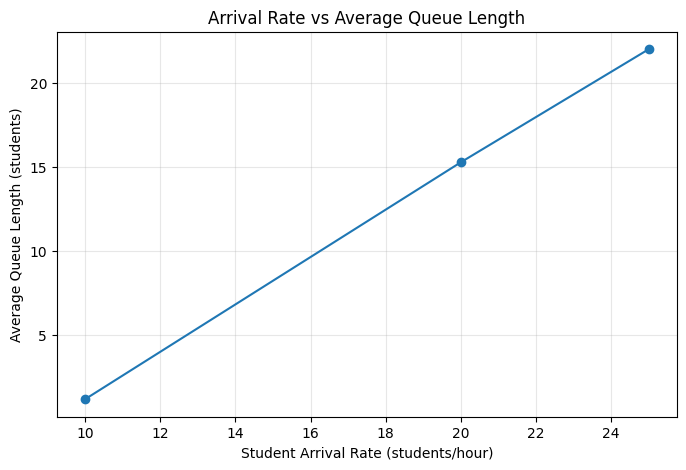

In [ ]:
# 11. GRAPH 2 - AVERAGE QUEUE LENGTH

plt.figure(figsize=(8, 5))

plt.plot(
    performance_summary["Arrival Rate (students/hour)"],
    performance_summary["Average Queue Length"],
    marker="o"
)

plt.xlabel("Student Arrival Rate (students/hour)")
plt.ylabel("Average Queue Length (students)")
plt.title("Arrival Rate vs Average Queue Length")

plt.grid(True, alpha=0.3)

plt.savefig(
    "EEI6373_Average_Queue_Length.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

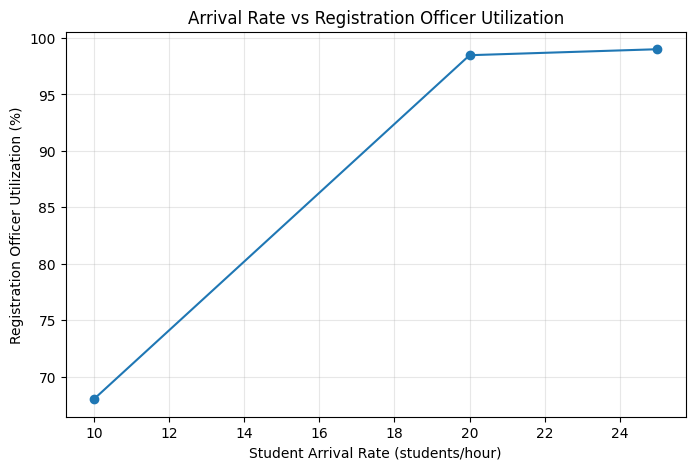

In [ ]:
# 12. GRAPH 3 - OFFICER UTILIZATION

plt.figure(figsize=(8, 5))

plt.plot(
    performance_summary["Arrival Rate (students/hour)"],
    performance_summary["Officer Utilization (%)"],
    marker="o"
)

plt.xlabel("Student Arrival Rate (students/hour)")
plt.ylabel("Registration Officer Utilization (%)")
plt.title("Arrival Rate vs Registration Officer Utilization")

plt.grid(True, alpha=0.3)

plt.savefig(
    "EEI6373_Officer_Utilization.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

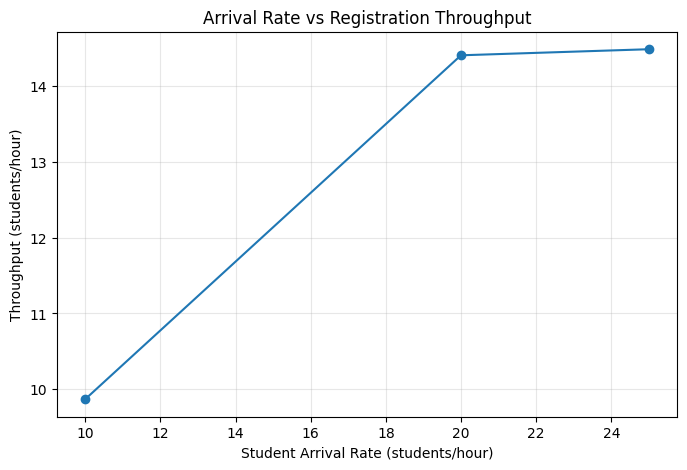

In [ ]:
# 13. GRAPH 4 - THROUGHPUT

plt.figure(figsize=(8, 5))

plt.plot(
    performance_summary["Arrival Rate (students/hour)"],
    performance_summary["Throughput (students/hour)"],
    marker="o"
)

plt.xlabel("Student Arrival Rate (students/hour)")
plt.ylabel("Throughput (students/hour)")
plt.title("Arrival Rate vs Registration Throughput")

plt.grid(True, alpha=0.3)

plt.savefig(
    "EEI6373_Registration_Throughput.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# 14. DOWNLOAD GRAPHS

files.download("EEI6373_Average_Waiting_Time.png")
files.download("EEI6373_Average_Queue_Length.png")
files.download("EEI6373_Officer_Utilization.png")
files.download("EEI6373_Registration_Throughput.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>